In [2]:
import torch
import torch.nn as nn
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import random

from pathlib import Path

from PIL import Image
import os


from torchvision import transforms
from torch.utils.data import (
    DataLoader,
    ConcatDataset,
    WeightedRandomSampler
)
from torchvision.datasets import ImageFolder
from torchvision.models import resnet18, ResNet18_Weights

from collections import Counter
import hashlib

from sklearn.model_selection import train_test_split
from torch.utils.data import Subset

from sklearn.metrics import (
    classification_report,
    f1_score
)

In [3]:
def file_hash(path):

    ## Return hashed library for image leakage between training and testing sets
    with open(path, "rb") as f:
        return hashlib.md5(f.read()).hexdigest()


In [4]:
def collect_image_hashes(folder, dataset_name):
    ## Create the image hashes to see image leakage between training and testing sets

    records = []

    for path in Path(folder).rglob("*"):

        if path.is_file():
            records.append({
                "dataset": dataset_name,
                "class": path.parent.name,
                "filename": path.name,
                "path": str(path),
                "hash": file_hash(path)
            })

    return records

In [6]:
## Load pre-trained weights from ResNet18 convolutional neural network

weights = ResNet18_Weights.DEFAULT


# =========================================================
# TRAINING TRANSFORM
# =========================================================

train_transform = transforms.Compose([

    transforms.Grayscale(num_output_channels=3),

    # Preserve the image's aspect ratio
    transforms.Resize(256),

    # Match the basic preprocessing used during evaluation
    transforms.CenterCrop(224),

    # Small random variations in position / scale / rotation
    transforms.RandomAffine(
        degrees=7,
        translate=(0.05, 0.05),
        scale=(0.9, 1.1)
    ),

    # A left/right flip should not change whether
    # an image represents flipping or not flipping
    transforms.RandomHorizontalFlip(p=0.5),

    # Simulate different lighting conditions
    transforms.ColorJitter(
        brightness=0.25,
        contrast=0.25,
        saturation=0.15
    ),

    transforms.ToTensor(),

    # ImageNet normalization used by pretrained ResNet18
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])


# =========================================================
# EVALUATION TRANSFORM
# =========================================================

eval_transform = weights.transforms()


# =========================================================
# TRAINING DATASETS
# =========================================================

# Original provided video
train_dataset = ImageFolder(
    "images/training_varied_inc_og_and_3",
    transform=train_transform
)


# =========================================================
# VALIDATION + TEST DATASETS
# =========================================================

# A DIFFERENT new recording.
# This video must not occur in either training folder.
val_dataset = ImageFolder(
    "images/validation_varied_inc_1_and_2",
    transform=eval_transform
)

# Original provided video's testing frames
test_dataset = ImageFolder(
    "images/testing_varied_jnc_4_and_5",
    transform=eval_transform
)

# =========================================================
# CHECK LABEL MAPPINGS
# =========================================================

assert (
    train_dataset.class_to_idx
    == val_dataset.class_to_idx
    == test_dataset.class_to_idx
)

In [16]:

# =========================================================
# DATALOADERS
# =========================================================

train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True
)


val_loader = DataLoader(
    val_dataset,
    batch_size=32,
    shuffle=False
)


test_loader = DataLoader(
    test_dataset,
    batch_size=32,
    shuffle=False
)


# =========================================================
# CHECK DATASETS
# =========================================================

print("\nNew training:")
print(Counter(train_dataset.targets))
print(train_dataset.class_to_idx)

print("\nValidation:")
print(Counter(val_dataset.targets))
print(val_dataset.class_to_idx)

print("\nOriginal test:")
print(Counter(test_dataset.targets))
print(test_dataset.class_to_idx)


New training:
Counter({1: 1731, 0: 1618})
{'flip': 0, 'notflip': 1}

Validation:
Counter({0: 190, 1: 168})
{'flip': 0, 'notflip': 1}

Original test:
Counter({1: 358, 0: 278})
{'flip': 0, 'notflip': 1}


In [17]:
# Initialize records to compare hashes
records = []

for classification in ["flip", "notflip"]:

    # Ensures to load images from each classification
    folder = f"images/training_varied_inc_og_and_3/{classification}"

    for filename in os.listdir(folder):

        # Combines file name with folder to get full path
        path = os.path.join(folder, filename)

        try:
            img = Image.open(path)

            # Keeps classification, filename, width, height and color/pixel mode.            
            records.append({"class": classification,
                "filename": filename,
                "width": img.width,
                "height": img.height,
                "mode": img.mode})

        except Exception:
            print("Could not open:", path)

# Creates dataframe of records
df = pd.DataFrame(records)

Could not open: images/training_varied_inc_og_and_3/notflip\.DS_Store


In [18]:
# Shows makeup of dataframe.
print(df.head())

# Standard deviation for height and width are both 0, so, all the dimensions are consistent.
print(df[["width", "height"]].describe())

# How many total colors/pixel formattings there are, of which there are 2392. Thus, all images are unique. 
print(df["mode"].value_counts())

  class            filename  width  height mode
0  flip  0001_000000010.jpg   1080    1920  RGB
1  flip  0001_000000011.jpg   1080    1920  RGB
2  flip  0001_000000012.jpg   1080    1920  RGB
3  flip  0001_000000013.jpg   1080    1920  RGB
4  flip  0001_000000014.jpg   1080    1920  RGB
             width       height
count  3349.000000  3349.000000
mean   1196.094357  2126.389967
std     334.570515   594.792027
min    1080.000000  1920.000000
25%    1080.000000  1920.000000
50%    1080.000000  1920.000000
75%    1080.000000  1920.000000
max    2160.000000  3840.000000
mode
RGB    3349
Name: count, dtype: int64


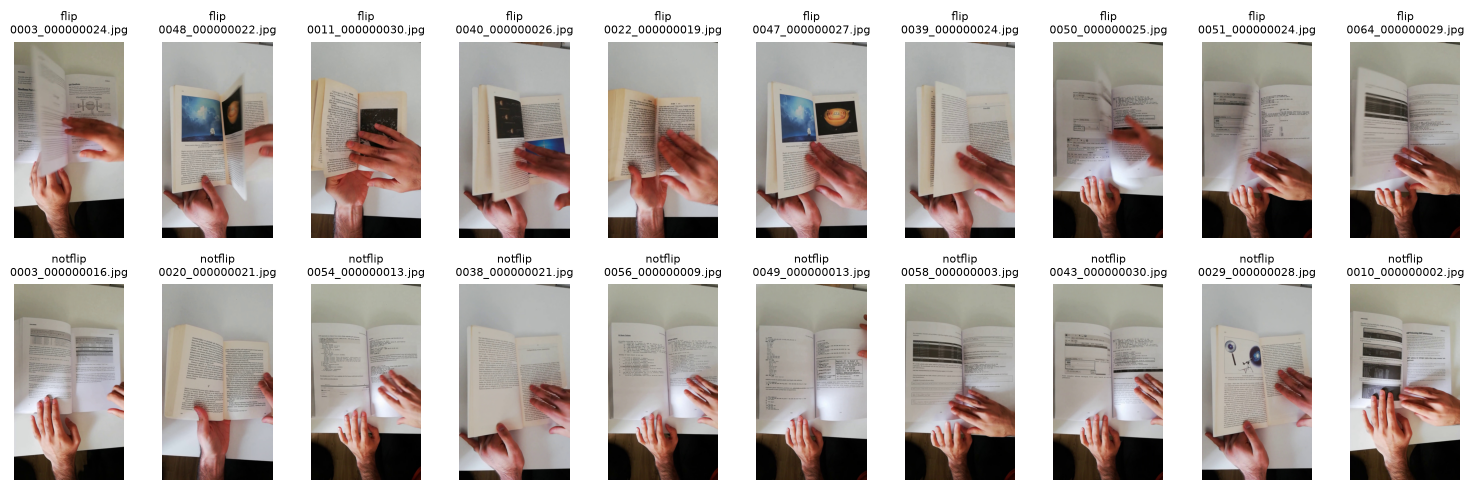

In [19]:
fig, axes = plt.subplots(2, 10, figsize=(15, 5))

for row, classification in enumerate(["flip", "notflip"]):

    folder = f"images/training/{classification}"
    files = random.sample(os.listdir(folder), 10)

    for col, filename in enumerate(files):

        img = Image.open(
            os.path.join(folder, filename)
        ).convert("RGB")

        axes[row, col].imshow(img)
        axes[row, col].set_title(f"{classification}\n{filename}", fontsize=8)
        axes[row, col].axis("off")

plt.tight_layout()
plt.show()

In [20]:
# Naming initial pre-trained model
model = resnet18(weights=weights)

# Ensuring the parameters are not changed using backpropagation for the initial model's layers

for param in model.parameters():
    param.requires_grad = False

for param in model.layer4.parameters():
    param.requires_grad = True

# Replacing original final layer with a new layer for feature representation to the 2 classes
model.fc = nn.Linear(model.fc.in_features, 2)

for param in model.fc.parameters():
    param.requires_grad = True
print(model.fc)

Linear(in_features=512, out_features=2, bias=True)


In [21]:
criterion = nn.CrossEntropyLoss()

In [22]:
# AdaM optimizer object to only update model.fc, with conservative learning rate of 0.001. 

optimizer = torch.optim.Adam([
    {"params": model.layer4.parameters(), "lr": 0.0001},
    {"params": model.fc.parameters(), "lr": 0.001}])

# Since running on Mac and Windows, checks for MPS, GPU, or CPU access to optimize batched learning
if torch.backends.mps.is_available():
    device = torch.device("mps")
elif torch.cuda.is_available():
    device = torch.device("cuda")
else:
    device = torch.device("cpu")

# Transfer model to chosen device
model = model.to(device)

print(device)

cpu


In [23]:
# Definining trackers and number of epochs when training
num_epochs = 20

train_losses = []
val_losses = []
train_accuracies = []
val_accuracies = []
train_f1s = []
val_f1s = []

best_val_loss = float("inf")
patience = 4
epochs_without_improvement = 0

for epoch in range(num_epochs):

    # Set NN into training mode
    model.train()

    # Initialize running loss and metrics needed to compute accuracy per epoch 
    running_loss = 0
    correct = 0
    total = 0

    train_predictions = []
    train_labels = []

    # For every batch of images with labels in the training loader
    for images, labels in train_loader:

        # Move images and labels to device
        images = images.to(device)
        labels = labels.to(device)

        # Clears old gradients
        optimizer.zero_grad()

        # Pass images through the network; output result
        outputs = model(images)

        # Cross entropy loss computed for outputs
        loss = criterion(outputs, labels)

        # Compute loss gradient
        loss.backward()

        # Changes linear coefficients using AdaM optimizer algorithm
        optimizer.step()

        # Update running loss batch-by-batch
        running_loss += loss.item() * labels.size(0)

        # Column index for output preds
        predictions = outputs.argmax(dim=1)

        train_predictions.extend(predictions.cpu().numpy())
        train_labels.extend(labels.cpu().numpy())

        # Update number of correct predictions, only when the preds are the same as the label
        correct += (predictions == labels).sum().item()

        # Updates total considered images
        total += labels.size(0)

    # Calculate training metrics for this epoch
    train_loss = running_loss / total
    train_accuracy = correct / total
    train_f1 = f1_score(train_labels, train_predictions, average="macro")


    # Validation mode for model
    model.eval()

    # Initialize validation tracking variables
    val_loss = 0
    val_correct = 0
    val_total = 0

    val_predictions = []
    val_labels = []

    # Ensures gradients are not saved
    with torch.no_grad():

        # Same process as training set training
        for images, labels in val_loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            loss = criterion(outputs, labels)

            val_loss += loss.item() * labels.size(0)

            predictions = outputs.argmax(dim=1)

            val_predictions.extend(predictions.cpu().numpy())
            val_labels.extend(labels.cpu().numpy())

            val_correct += (predictions == labels).sum().item()
            val_total += labels.size(0)

    # Calculate validation metrics for this epoch
    val_loss = val_loss / val_total
    val_accuracy = val_correct / val_total
    val_f1 = f1_score(val_labels, val_predictions, average="macro")

    # Save metrics from THIS epoch
    train_losses.append(train_loss)
    val_losses.append(val_loss)

    train_accuracies.append(train_accuracy)
    val_accuracies.append(val_accuracy)

    train_f1s.append(train_f1)
    val_f1s.append(val_f1)


    # Prints epoch number, train/val loss and train/val accuracy
    print(f"Epoch {epoch + 1}/{num_epochs} | "
          f"Train Loss: {train_loss:.4f} | "
          f"Train Acc: {train_accuracy:.3f} | "
          f"Train F1: {train_f1:.3f} | "
          f"Val Loss: {val_loss:.4f} | "
          f"Val Acc: {val_accuracy:.3f} | "
          f"Val F1: {val_f1:.3f}")

    if val_loss < best_val_loss:

        best_val_loss = val_loss
        epochs_without_improvement = 0

        torch.save(
            model.state_dict(),
            "best_resnet18_flip_classifier_w_new_val.pth"
        )

        print("Best model saved.")

    else:

        epochs_without_improvement += 1

    if epochs_without_improvement >= patience:
        print("Early stopping.")
        break

model.load_state_dict(
    torch.load(
        "best_resnet18_flip_classifier_w_new_val.pth",
        map_location=device,
        weights_only=True
    )
)

model.eval()

print(f"Best validation loss: {best_val_loss:.4f}")

Epoch 1/20 | Train Loss: 0.3682 | Train Acc: 0.825 | Train F1: 0.825 | Val Loss: 1.1480 | Val Acc: 0.531 | Val F1: 0.347
Best model saved.
Epoch 2/20 | Train Loss: 0.2108 | Train Acc: 0.904 | Train F1: 0.903 | Val Loss: 1.1545 | Val Acc: 0.531 | Val F1: 0.347


KeyboardInterrupt: 

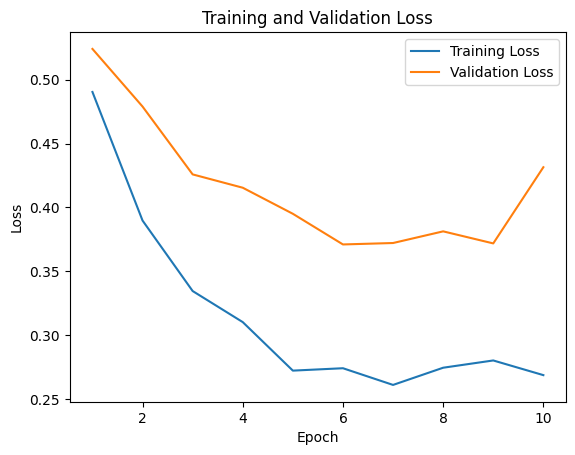

In [ ]:
epochs = range(1, len(train_losses) + 1)


## Plotting loss per epoch
plt.figure()

plt.plot(epochs, train_losses, label="Training Loss")
plt.plot(epochs, val_losses, label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")

plt.legend()
plt.show()

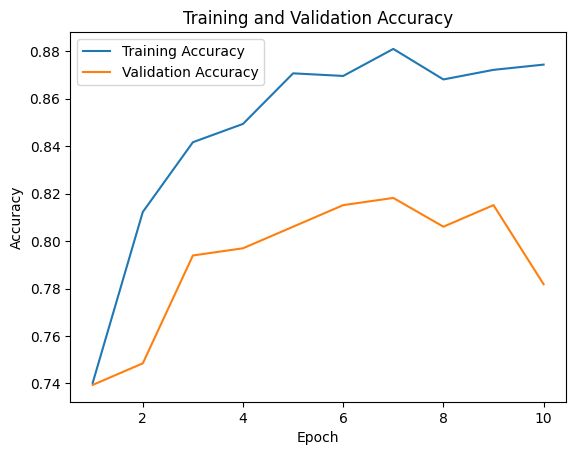

In [ ]:
## Plotting accuracy over time
plt.figure()

plt.plot(epochs, train_accuracies, label="Training Accuracy")
plt.plot(epochs, val_accuracies, label="Validation Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training and Validation Accuracy")

plt.legend()
plt.show()

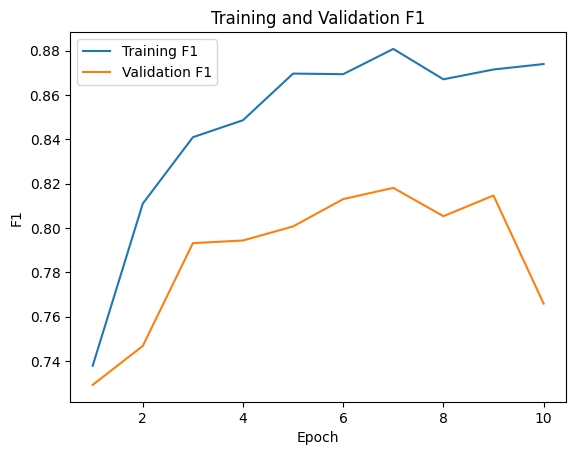

In [ ]:
## Plotting F1 over time
plt.figure()

plt.plot(epochs, train_f1s, label="Training F1")
plt.plot(epochs, val_f1s, label="Validation F1")

plt.xlabel("Epoch")
plt.ylabel("F1")
plt.title("Training and Validation F1")

plt.legend()
plt.show()

In [ ]:
all_predictions = []
all_labels = []

model.eval()

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)

        outputs = model(images)
        predictions = outputs.argmax(dim=1)

        all_predictions.extend(predictions.cpu().numpy())
        all_labels.extend(labels.numpy())

print(
    classification_report(
        all_labels,
        all_predictions,
        target_names=test_dataset.classes
    )
)

torch.save(
    model.state_dict(),
    "resnet18_flip_classifier.pth"
)

{'flip': 0, 'notflip': 1}
{'flip': 0, 'notflip': 1}
{'flip': 0, 'notflip': 1}
              precision    recall  f1-score   support

        flip       0.95      0.99      0.97       290
     notflip       0.99      0.95      0.97       307

    accuracy                           0.97       597
   macro avg       0.97      0.97      0.97       597
weighted avg       0.97      0.97      0.97       597



In [ ]:
false_flips = []

flip_idx = test_dataset.class_to_idx["flip"]
notflip_idx = test_dataset.class_to_idx["notflip"]

model.eval()

with torch.no_grad():

    for images, labels in test_loader:

        outputs = model(images.to(device))
        predictions = outputs.argmax(dim=1).cpu()

        for image, true_label, predicted_label in zip(
            images,
            labels,
            predictions
        ):

            # We specifically want:
            # TRUE = notflip
            # PREDICTED = flip

            if (
                true_label.item() == notflip_idx
                and predicted_label.item() == flip_idx
            ):

                false_flips.append(image)

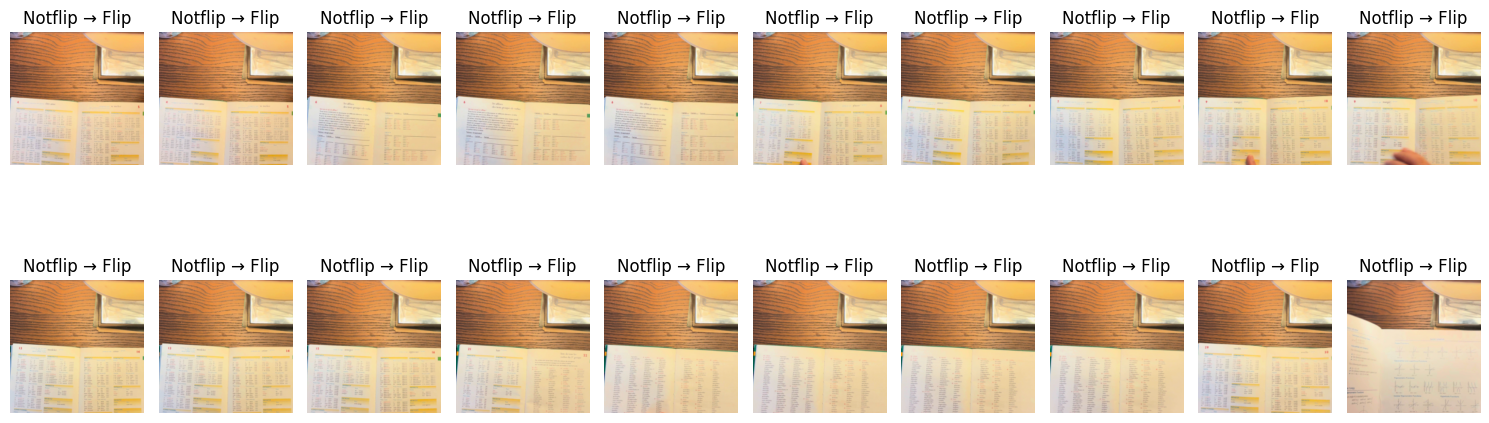

In [ ]:
# ImageNet normalization values
mean = torch.tensor(
    [0.485, 0.456, 0.406]
).view(3, 1, 1)

std = torch.tensor(
    [0.229, 0.224, 0.225]
).view(3, 1, 1)


num_to_show = min(20, len(false_flips))

fig, axes = plt.subplots(
    2,
    10,
    figsize=(15, 6)
)

axes = axes.flatten()

for i in range(num_to_show):

    image = false_flips[i]

    # Undo normalization so the image looks normal
    image = image * std + mean
    image = image.clamp(0, 1)

    # PyTorch:
    # channels × height × width
    #
    # matplotlib:
    # height × width × channels

    image = image.permute(1, 2, 0)

    axes[i].imshow(image)
    axes[i].set_title("Notflip → Flip")
    axes[i].axis("off")


# Hide unused positions
for i in range(num_to_show, len(axes)):
    axes[i].axis("off")


plt.tight_layout()
plt.show()